In [215]:
import pandas as pd
import vectorbt as vbt
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler, TPESampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals
from ggTrader.Utils import *


In [216]:
top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

Walk Forward Optimization

In [217]:
# setup
k = KrakenHistoricalData()
kd = KrakenData()

start_equity = 1000
symbols = [top_kraken[0]]
interval = "4h"
n_trials = 100  # per window
sampler = TPESampler()
optuna.logging.set_verbosity(optuna.logging.WARNING)  # or ERROR / CRITICAL

# Entire time range
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = pd.to_datetime("2023-01-01").tz_localize('UTC')

# Default Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 3,
          'adx_threshold': 0,  # has little affect
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 22,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }
# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)

df_multi = k.get_ohlcv_df(symbols, interval=interval)
# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]




                                   close       equity
2025-09-28 12:00:00+00:00  110011.101562  6659.549805
2025-09-28 16:00:00+00:00  110353.203125  6680.258301
2025-09-28 20:00:00+00:00  112127.796875  6787.684570
2025-09-29 00:00:00+00:00  111862.500000  6771.624023
2025-09-29 04:00:00+00:00  111863.601562  6771.690918
2025-09-29 08:00:00+00:00  112093.398438  6785.602051
2025-09-29 12:00:00+00:00  113844.000000  6891.575195
2025-09-29 16:00:00+00:00  114358.296875  6922.708008
2025-09-29 20:00:00+00:00  114365.203125  6923.125977
2025-09-30 00:00:00+00:00  114430.601562  6927.084961


Computed test_size=668, max_train_size=2672


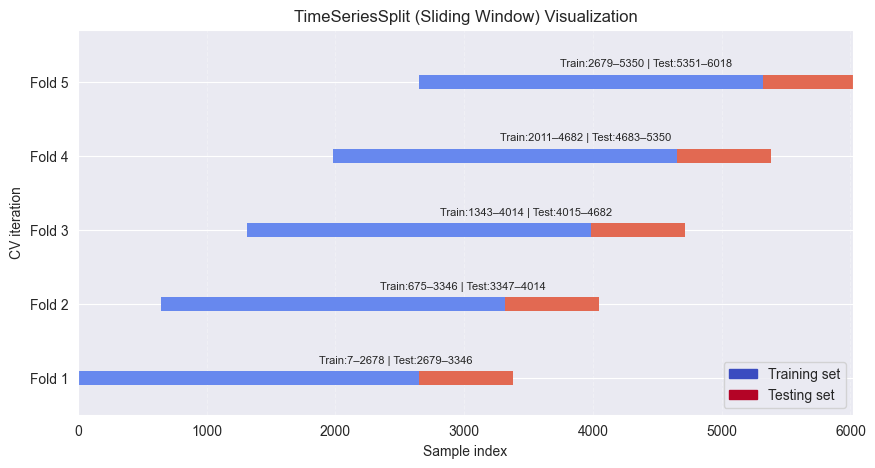

Fold 1: Train [2023-01-02 04:00:00+00:00–2024-03-22 08:00:00+00:00] (445), Test [2024-03-22 12:00:00+00:00–2024-07-11 16:00:00+00:00] (111)
Fold 2: Train [2023-04-23 12:00:00+00:00–2024-07-11 16:00:00+00:00] (445), Test [2024-07-11 20:00:00+00:00–2024-10-31 00:00:00+00:00] (111)
Fold 3: Train [2023-08-12 20:00:00+00:00–2024-10-31 00:00:00+00:00] (445), Test [2024-10-31 04:00:00+00:00–2025-02-19 08:00:00+00:00] (111)
Fold 4: Train [2023-12-02 04:00:00+00:00–2025-02-19 08:00:00+00:00] (445), Test [2025-02-19 12:00:00+00:00–2025-06-10 16:00:00+00:00] (111)
Fold 5: Train [2024-03-22 12:00:00+00:00–2025-06-10 16:00:00+00:00] (445), Test [2025-06-10 20:00:00+00:00–2025-09-30 00:00:00+00:00] (111)


In [218]:
# Train split
n_splits = 5
test_ratio = 0.2
tscv, test_size, max_train_size = make_end_anchored_tscv(n_samples=len(df), n_splits=n_splits, test_ratio=test_ratio)
print(f"Computed test_size={test_size}, max_train_size={max_train_size}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_cv_indices(tscv, df.index, ax, n_splits)
plt.show()

# 4. Print fold ranges
for i, (tr, tt) in enumerate(tscv.split(df.index), 1):
    print(
        f"Fold {i}: Train [{df.index[tr[0]]}–{df.index[tr[-1]]}] ({len(tr) / 6:.0f}), Test [{df.index[tt[0]]}–{df.index[tt[-1]]}] ({len(tt) / 6:.0f})")

Optuna setup

In [219]:
best_params_list = []
value_list = []

for i, (tr, tt) in enumerate(tscv.split(df.index), 1):
    df_train = df.iloc[tr]
    df_test = df.iloc[tt]
    print(f"{symbols[0]} Fold {i}/{n_splits}:")


    def objective(trial):
        params['atr_multiplier'] = trial.suggest_float("atr_multiplier", 1, 3, step=0.1)
        params['ce_low_length'] = trial.suggest_int("ce_low_length", 1, 20)

        s = Signals(**params)

        signals = s.calc_signals(df_train.copy())
        close = signals['close']
        entries = signals['entry_signal']
        exits = signals['exit_signal']
        # Build target allocation:
        # 1.0 = 100% of portfolio in asset
        # 0.0 = 100% in cash
        size = pd.Series(np.nan, index=close.index)
        size[entries] = 1.0   # on buy signal: go all-in
        size[exits] = 0.0     # on sell signal: go flat

        pf = vbt.Portfolio.from_orders(
            close=close,
            size=size,
            size_type='targetpercent',  # interpret `size` as target weight
            direction='longonly',
            init_cash=start_equity,           # starting cash
            fees=transaction_fee,                 # 0.1% fee (optional)
            slippage=0.0005,            # optional
        )
        stats = pf.stats()
        sharpe = stats['Sharpe Ratio']
        if sharpe is None or math.isnan(sharpe) or math.isinf(sharpe):
            raise optuna.exceptions.TrialPruned("Invalid objective (NaN/Inf).")
        return sharpe


    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params
    best_params_list.append(best_params)

    # backtest best parameters on test set
    for param in best_params.keys():
        params[param] = best_params[param]

    s = Signals(**params)

    signals = s.calc_signals(df_train.copy())
    close = signals['close']
    entries = signals['entry_signal']
    exits = signals['exit_signal']
    # Build target allocation:
    # 1.0 = 100% of portfolio in asset
    # 0.0 = 100% in cash
    size = pd.Series(np.nan, index=close.index)
    size[entries] = 1.0   # on buy signal: go all-in
    size[exits] = 0.0     # on sell signal: go flat

    pf = vbt.Portfolio.from_orders(
        close=close,
        size=size,
        size_type='targetpercent',  # interpret `size` as target weight
        direction='longonly',
        init_cash=start_equity,           # starting cash
        fees=transaction_fee,                 # 0.1% fee (optional)
        slippage=0.0005,            # optional
    )
    stats = pf.stats()
    sharpe = stats['Sharpe Ratio']
    # sortino = stats['Sortino Ratio']
    value_list.append(sharpe)

print(f"...Optimization Complete")

BTC Fold 1/5:
BTC Fold 2/5:
BTC Fold 3/5:
BTC Fold 4/5:
BTC Fold 5/5:
...Optimization Complete


In [220]:
print("\nWalk Forward Optimization Results:")
rows = [{**p, "score": float(s), "fold": i + 1} for i, (p, s) in enumerate(zip(best_params_list, value_list))]
df_result = pd.DataFrame(rows).set_index("fold")
print(tabulate(df_result, headers="keys", tablefmt="github"))
result_stats = df_result.describe()

print("\nWalk Forward Optimization Stats:")
print(tabulate(result_stats, headers="keys", tablefmt="github"))

avg = df_result.mean(numeric_only=True)  # returns a Series with column averages

params['atr_multiplier'] = round(avg['atr_multiplier'], 1)
params['ce_low_length'] = int(avg['ce_low_length'])



Walk Forward Optimization Results:
|   fold |   atr_multiplier |   ce_low_length |    score |
|--------|------------------|-----------------|----------|
|      1 |              1.1 |               1 |  5.56685 |
|      2 |              1.1 |               1 | 11.6205  |
|      3 |              1.1 |               1 | 13.6878  |
|      4 |              1   |               1 | 13.0587  |
|      5 |              1   |               1 | 10.2269  |

Walk Forward Optimization Stats:
|       |   atr_multiplier |   ce_low_length |    score |
|-------|------------------|-----------------|----------|
| count |        5         |               5 |  5       |
| mean  |        1.06      |               1 | 10.8321  |
| std   |        0.0547723 |               0 |  3.23356 |
| min   |        1         |               1 |  5.56685 |
| 25%   |        1         |               1 | 10.2269  |
| 50%   |        1.1       |               1 | 11.6205  |
| 75%   |        1.1       |               1 | 13.058

Run final backtest with average parameters

In [221]:
for param in best_params.keys():
    params[param] = best_params[param]

s = Signals(**params)

signals = s.calc_signals(df.copy())
close = signals['close']
entries = signals['entry_signal']
exits = signals['exit_signal']
# Build target allocation:
# 1.0 = 100% of portfolio in asset
# 0.0 = 100% in cash
size = pd.Series(np.nan, index=close.index)
size[entries] = 1.0   # on buy signal: go all-in
size[exits] = 0.0     # on sell signal: go flat

pf = vbt.Portfolio.from_orders(
    close=close,
    size=size,
    size_type='targetpercent',  # interpret `size` as target weight
    direction='longonly',
    init_cash=start_equity,           # starting cash
    fees=transaction_fee,                 # 0.1% fee (optional)
    slippage=0.0005,            # optional
)
stats = pf.stats()
print(stats)

| 0                |     1 |
|------------------|-------|
| sar_acceleration |  0.02 |
| sar_maximum      |  0.2  |
| atr_multiplier   |  1.1  |
| adx_threshold    |  0    |
| adx_length       | 14    |
| ce_high_length   | 22    |
| ce_low_length    |  1    |
| atr_length       | 14    |

Final Backtest Stats:
| 0                |            1 |
|------------------|--------------|
| trading_days     |   1003       |
| total_profit     | 123096       |
| total_profit_pct |  12309.6     |
| sharpe           |      6.31709 |
| sortino          |     12.7734  |
| wins             |    216       |
| losses           |     24       |
| win_rate         |     90       |
                              timestamp  sar_acceleration  sar_maximum  \
symbol                                                                   
BTC    2025-11-08 03:35:50.248278+00:00              0.02          0.2   

        atr_multiplier  adx_threshold  adx_length  ce_high_length  \
symbol                             

In [ ]:
pf.plot(width=1600, height=1500).show()

In [222]:
# # Python
# from pathlib import Path
# import pandas as pd
#
# def load_or_create_csv(path, columns=None):
#     p = Path(path)
#     if p.exists():
#         return pd.read_csv(p,index_col=0)
#     # create empty DataFrame with optional columns
#     return pd.DataFrame(columns=columns or [])
#
# filename = "optimization_results.csv"
# df_stats_csv = load_or_create_csv(filename)
# print(df_stats_csv)
# df_stats_csv  = pd.concat([df_stats_csv, df_stats], ignore_index=False)
# print(df_stats_csv)
# df_stats_csv.to_csv(filename)

                               timestamp  sar_acceleration  sar_maximum  \
symbol                                                                    
BTC     2025-11-08 02:35:50.134138+00:00              0.02          0.2   
ETH     2025-11-08 02:42:15.182440+00:00              0.02          0.2   
XRP     2025-11-08 02:43:17.364442+00:00              0.02          0.2   
BNB     2025-11-08 02:45:04.034059+00:00              0.02          0.2   
SOL     2025-11-08 02:46:40.654777+00:00              0.02          0.2   
TRX     2025-11-08 02:48:13.348734+00:00              0.02          0.2   
DOGE    2025-11-08 02:49:42.287719+00:00              0.02          0.2   
ADA     2025-11-08 02:51:51.346010+00:00              0.02          0.2   
LINK    2025-11-08 02:53:26.277189+00:00              0.02          0.2   
BCH     2025-11-08 02:54:25.745599+00:00              0.02          0.2   

        atr_multiplier  adx_threshold  adx_length  ce_high_length  \
symbol                        

Test on latest result for the last 3 months